In [1]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pandas numpy matplotlib seaborn mysql-connector-python

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.8 MB 2.6 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.8 MB 2.7 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.8 MB 2.9 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.8 MB 3.2 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.8 MB 3.6 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.8 MB 4.0 MB/s eta 0:00:02
   ---------------------------- ----------- 7.1/9.8 MB 4.5 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.8 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 5.0 MB/s  0:00:02
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------ --------------------------------- 1.6/

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [5]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Shashank@143",
    database="banking_analytics"
)

print("Connected successfully!")

Connected successfully!


In [6]:
customers = pd.read_sql(
    "SELECT * FROM customers",
    conn
)

customers.head()

C:\Users\shash\AppData\Local\Temp\ipykernel_15152\3943149022.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql(


,customer_id,age,gender,city,occupation,annual_income,customer_since,state,income_band
0,C102908,51,Female,Bengaluru,Business Owner,2561400.0,24-02-2020,Karnataka,High
1,C101971,42,Male,Delhi,IT Professional,2250900.0,09-06-2019,Delhi,High
2,C102209,50,Male,Kolkata,Government Employee,2180800.0,28-05-2019,West Bengal,High
3,C101745,46,Female,Pune,Government Employee,2163400.0,06-12-2024,Maharashtra,High
4,C103962,39,Male,Delhi,Self Employed,2149500.0,21-05-2022,Delhi,High


In [7]:
customers.shape

(5000, 9)

In [8]:
customers.columns

Index(['customer_id', 'age', 'gender', 'city', 'occupation', 'annual_income',
       'customer_since', 'state', 'income_band'],
      dtype='str')

In [11]:
customers.describe()

,age,annual_income
count,5000.00000,4.999000e+03
mean,35.24260,6.060219e+05
std,8.51863,2.853744e+05
min,21.00000,1.800000e+05
25%,29.00000,4.021000e+05
50%,35.00000,5.472000e+05
75%,41.00000,7.439500e+05
max,65.00000,2.561400e+06


In [10]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     5000 non-null   str    
 1   age             5000 non-null   int64  
 2   gender          5000 non-null   str    
 3   city            5000 non-null   str    
 4   occupation      5000 non-null   str    
 5   annual_income   4999 non-null   float64
 6   customer_since  5000 non-null   str    
 7   state           5000 non-null   str    
 8   income_band     4999 non-null   str    
dtypes: float64(1), int64(1), str(7)
memory usage: 351.7 KB


In [12]:
customers.isnull().sum()

customer_id       0
age               0
gender            0
city              0
occupation        0
annual_income     1
customer_since    0
state             0
income_band       1
dtype: int64

In [13]:
customers.duplicated().sum()

np.int64(0)

In [14]:
customers["gender"].value_counts()

gender
Male      2676
Female    2225
Other       99
Name: count, dtype: int64

In [15]:
customers["gender"].value_counts(normalize=True) * 100

gender
Male      53.52
Female    44.50
Other      1.98
Name: proportion, dtype: float64

In [16]:
customers["occupation"].value_counts()

occupation
Private Employee       1432
IT Professional        1094
Self Employed           615
Business Owner          607
Government Employee     593
Student                 416
Other                   242
Unknown                   1
Name: count, dtype: int64

In [17]:
customers["city"].value_counts()

city
Bengaluru    970
Mumbai       794
Delhi        698
Hyderabad    523
Pune         480
Chennai      467
Kolkata      365
Jaipur       289
Ahmedabad    278
Kochi        135
unknown        1
Name: count, dtype: int64

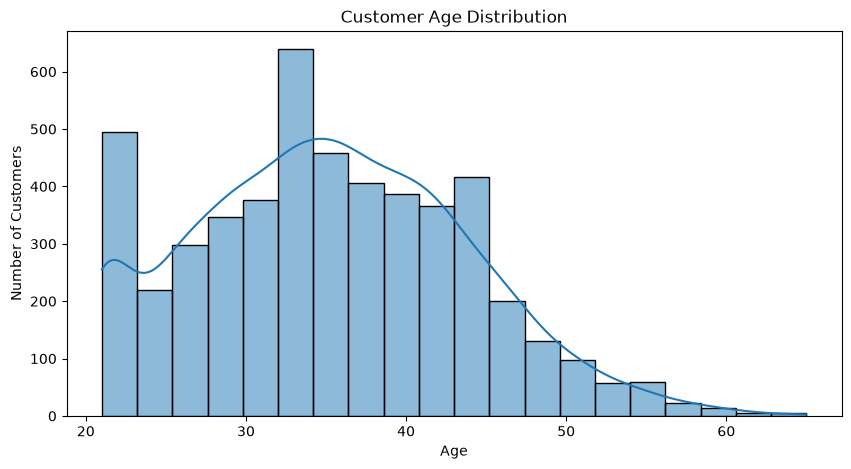

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    customers["age"],
    bins=20,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

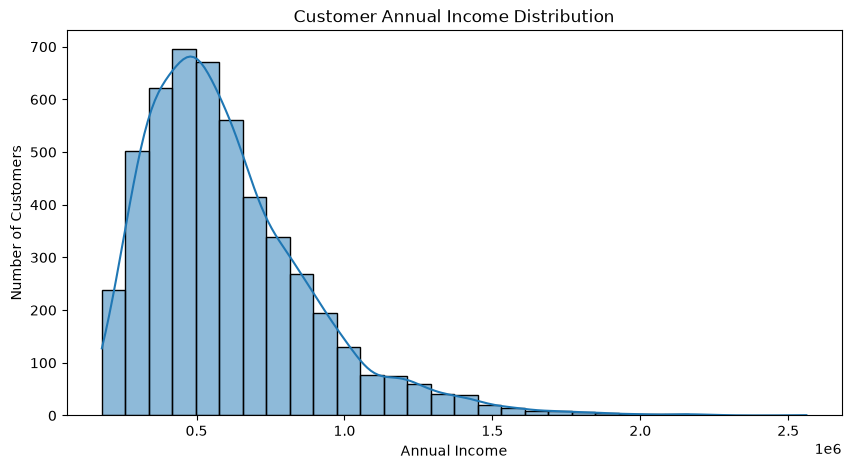

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    customers["annual_income"],
    bins=30,
    kde=True
)

plt.title("Customer Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")

plt.show()

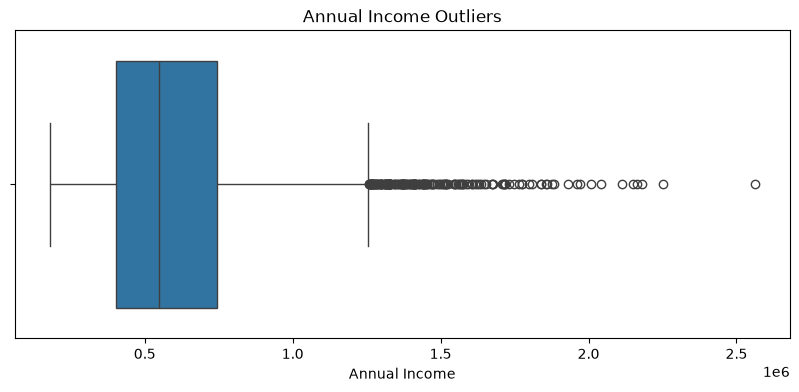

In [20]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=customers["annual_income"]
)

plt.title("Annual Income Outliers")
plt.xlabel("Annual Income")

plt.show()

In [21]:
customers["income_band"].value_counts()

income_band
Lower-Middle    2436
Upper-Middle    1664
Low              459
High             440
Name: count, dtype: int64

In [22]:
customers["income_band"].value_counts(normalize=True) * 100

income_band
Lower-Middle    48.729746
Upper-Middle    33.286657
Low              9.181836
High             8.801760
Name: proportion, dtype: float64

In [23]:
city_income = (
    customers
    .groupby("city")["annual_income"]
    .mean()
    .sort_values(ascending=False)
)

city_income

city
Delhi        626896.275072
Jaipur       625782.006920
Hyderabad    616839.196941
unknown      616000.000000
Ahmedabad    612650.359712
Kolkata      605614.010989
Bengaluru    601961.546392
Chennai      598883.083512
Pune         595317.916667
Mumbai       593097.607053
Kochi        569204.444444
Name: annual_income, dtype: float64

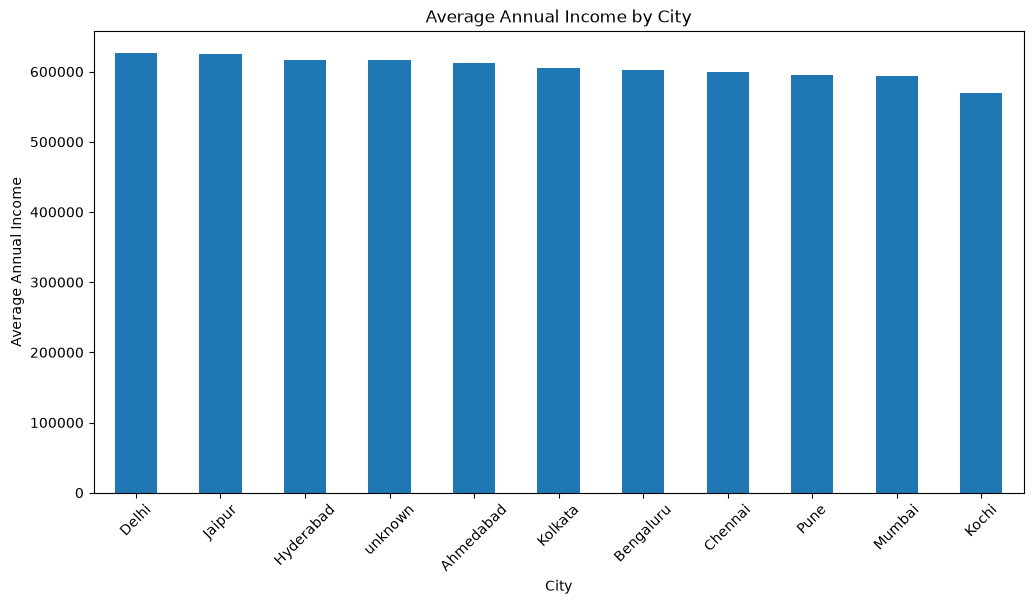

In [25]:
plt.figure(figsize=(12,6))

city_income.plot(kind="bar")

plt.title("Average Annual Income by City")
plt.xlabel("City")
plt.ylabel("Average Annual Income")

plt.xticks(rotation=45)

plt.show()

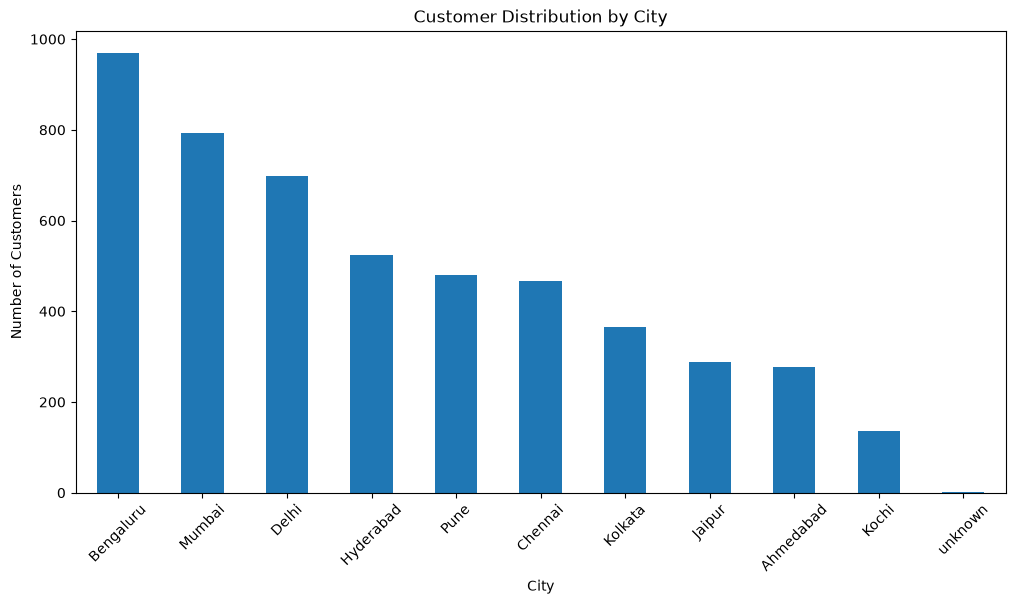

In [26]:
city_counts = customers["city"].value_counts()

plt.figure(figsize=(12,6))

city_counts.plot(kind="bar")

plt.title("Customer Distribution by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

In [27]:
transactions = pd.read_sql(
    "SELECT * FROM transactions1",
    conn
)

C:\Users\shash\AppData\Local\Temp\ipykernel_15152\3844336104.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions = pd.read_sql(


In [28]:
transactions = pd.read_sql(
    "SELECT * FROM transactions1",
    conn
)

print(transactions.shape)

C:\Users\shash\AppData\Local\Temp\ipykernel_15152\2018873425.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions = pd.read_sql(


(80000, 9)


In [29]:
transactions.shape

(80000, 9)

In [30]:
transactions.describe

<bound method NDFrame.describe of       transaction_id customer_id transaction_date transaction_type    amount  \
0            T300000     C102781       16-03-2025           Credit   1662.67   
1            T300001     C102559       08-07-2025           Credit   2271.15   
2            T300002     C102036       03-01-2025           Credit    881.14   
3            T300003     C100989       10-06-2025            Debit   1206.97   
4            T300004     C102631       01-05-2025            Debit   1252.07   
...              ...         ...              ...              ...       ...   
79995        T379996     C100676       02-08-2025            Debit   1469.37   
79996        T379997     C101722       07-08-2025           Credit    134.96   
79997        T379998     C101302       08-04-2025           Credit    628.81   
79998        T379999     C104164       01-01-2025           Credit  17525.82   
79999        T300250     C102208       2026-06-29            Debit       NaN   

     

In [31]:
transactions.columns


Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_type',
       'amount', 'channel', 'merchant_category', 'Month', 'month date'],
      dtype='str')

In [32]:
transactions.info()


<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     80000 non-null  str    
 1   customer_id        80000 non-null  str    
 2   transaction_date   80000 non-null  str    
 3   transaction_type   80000 non-null  str    
 4   amount             79999 non-null  float64
 5   channel            80000 non-null  str    
 6   merchant_category  80000 non-null  str    
 7   Month              80000 non-null  str    
 8   month date         80000 non-null  str    
dtypes: float64(1), str(8)
memory usage: 5.5 MB


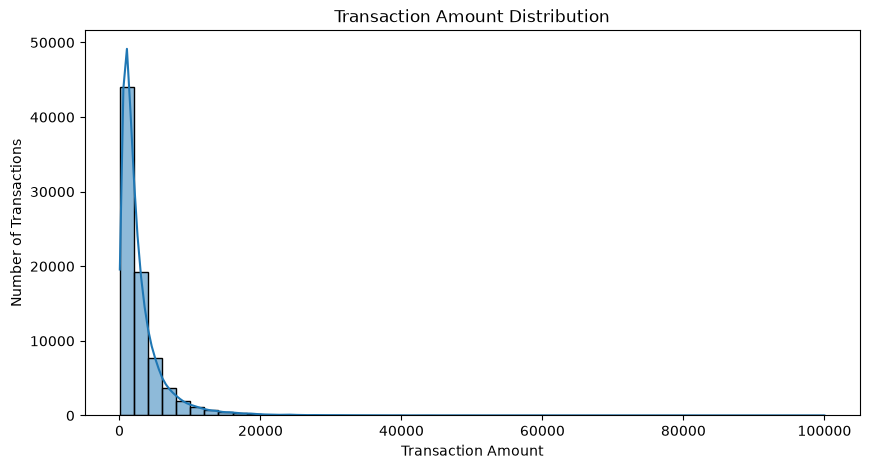

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    transactions["amount"].dropna(),
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

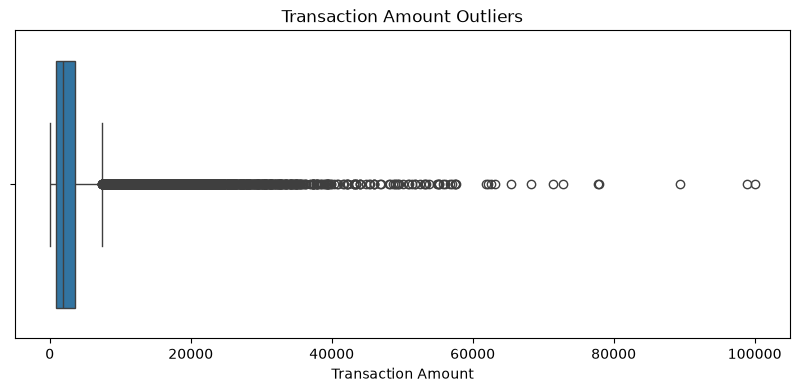

In [34]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=transactions["amount"]
)

plt.title("Transaction Amount Outliers")
plt.xlabel("Transaction Amount")

plt.show()

In [35]:
transactions["transaction_type"].value_counts()

transaction_type
Debit     46317
Credit    33683
Name: count, dtype: int64

In [36]:
transactions["transaction_type"].value_counts(normalize=True) * 100

transaction_type
Debit     57.89625
Credit    42.10375
Name: proportion, dtype: float64

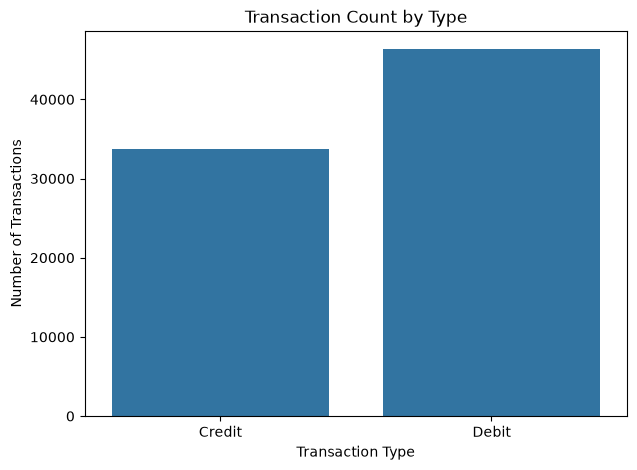

In [37]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=transactions,
    x="transaction_type"
)

plt.title("Transaction Count by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

In [38]:
transactions["channel"].value_counts()

channel
UPI            34480
Card           19232
Net Banking    14424
ATM             7869
Branch          3994
upi                1
Name: count, dtype: int64

In [39]:
transactions["channel"].value_counts(normalize=True) * 100

channel
UPI            43.10000
Card           24.04000
Net Banking    18.03000
ATM             9.83625
Branch          4.99250
upi             0.00125
Name: proportion, dtype: float64

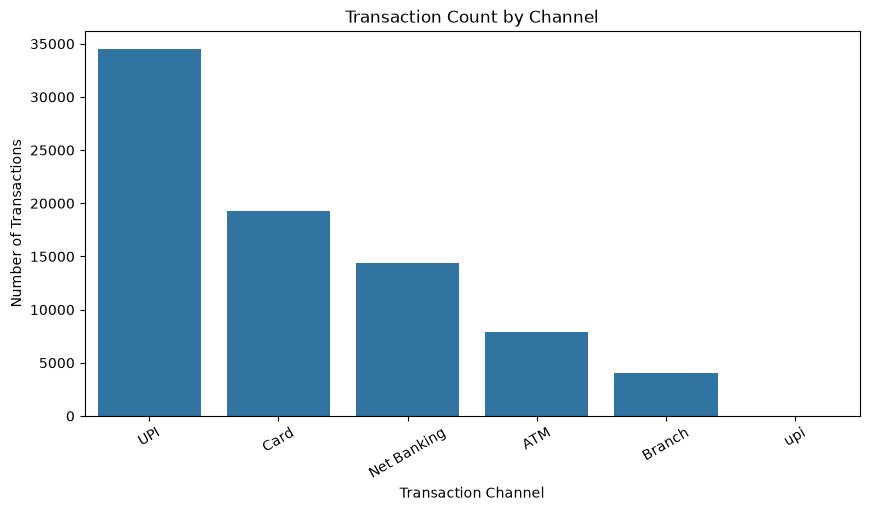

In [40]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=transactions,
    x="channel",
    order=transactions["channel"].value_counts().index
)

plt.title("Transaction Count by Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)

plt.show()

In [41]:
channel_value = (
    transactions
    .groupby("channel")["amount"]
    .sum()
    .sort_values(ascending=False)
)

channel_value

channel
UPI            1.022302e+08
Card           5.704587e+07
Net Banking    4.276284e+07
ATM            2.381482e+07
Branch         1.187159e+07
upi            1.760960e+03
Name: amount, dtype: float64

In [42]:
transactions["channel"] = transactions["channel"].str.upper()

In [43]:
transactions["channel"].value_counts()

channel
UPI            34481
CARD           19232
NET BANKING    14424
ATM             7869
BRANCH          3994
Name: count, dtype: int64

In [49]:
channel_value = (
    transactions
    .groupby("channel")["amount"]
    .sum()
    .sort_values(ascending=False)
)

channel_value

channel
UPI            1.022320e+08
CARD           5.704587e+07
NET BANKING    4.276284e+07
ATM            2.381482e+07
BRANCH         1.187159e+07
Name: amount, dtype: float64

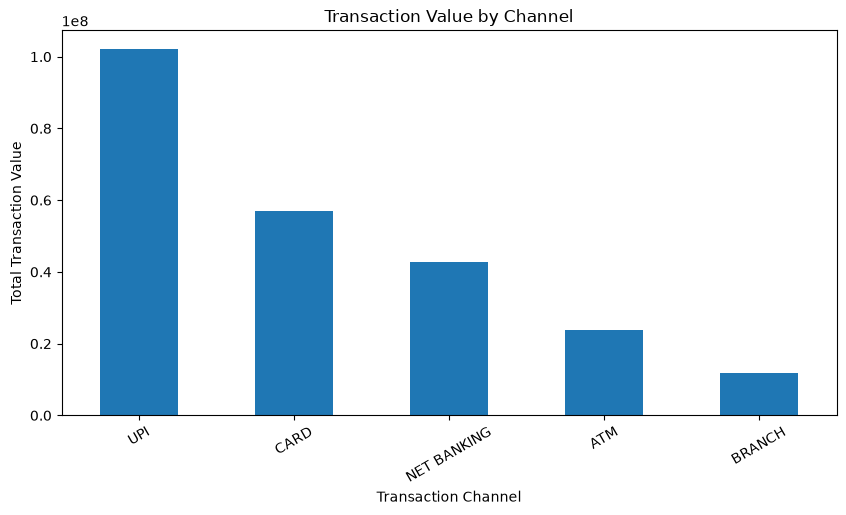

In [50]:
plt.figure(figsize=(10, 5))

channel_value.plot(kind="bar")

plt.title("Transaction Value by Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Total Transaction Value")
plt.xticks(rotation=30)

plt.show()

In [51]:
merchant_counts = (
    transactions["merchant_category"]
    .value_counts()
)

merchant_counts

merchant_category
Groceries        14490
Shopping         11170
Bills            10337
Travel            9640
Dining            7950
Fuel              7234
Healthcare        5612
Education         4826
Other             4784
Entertainment     3957
Name: count, dtype: int64

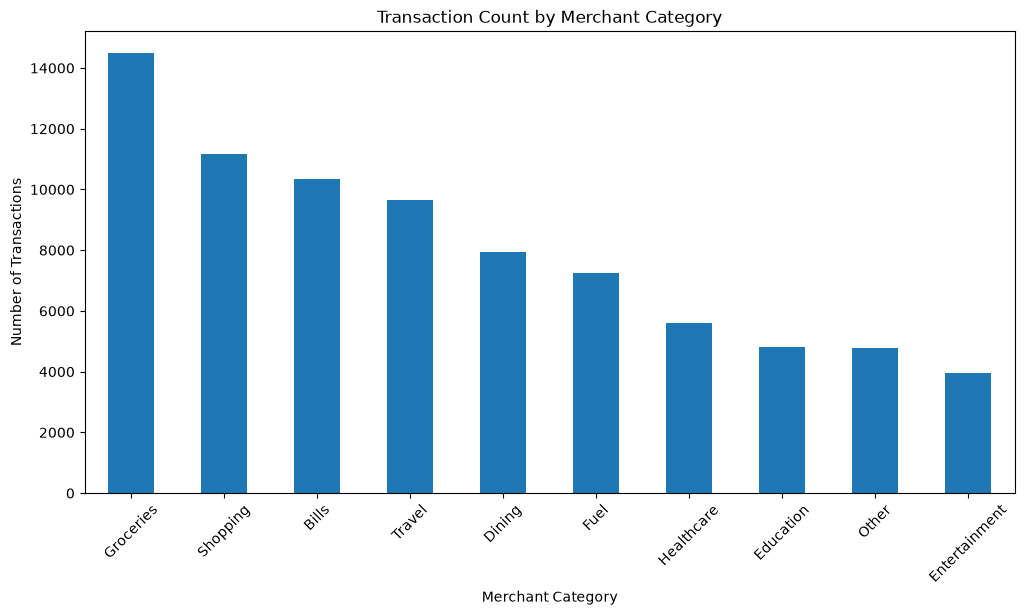

In [52]:
plt.figure(figsize=(12, 6))

merchant_counts.plot(kind="bar")

plt.title("Transaction Count by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [53]:
merchant_value = (
    transactions
    .groupby("merchant_category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

merchant_value

merchant_category
Groceries        43058619.59
Shopping         33238449.49
Bills            31003506.40
Travel           28446998.64
Dining           23297199.20
Fuel             21963974.55
Healthcare       16649890.30
Education        14353878.17
Other            14111270.79
Entertainment    11603315.22
Name: amount, dtype: float64

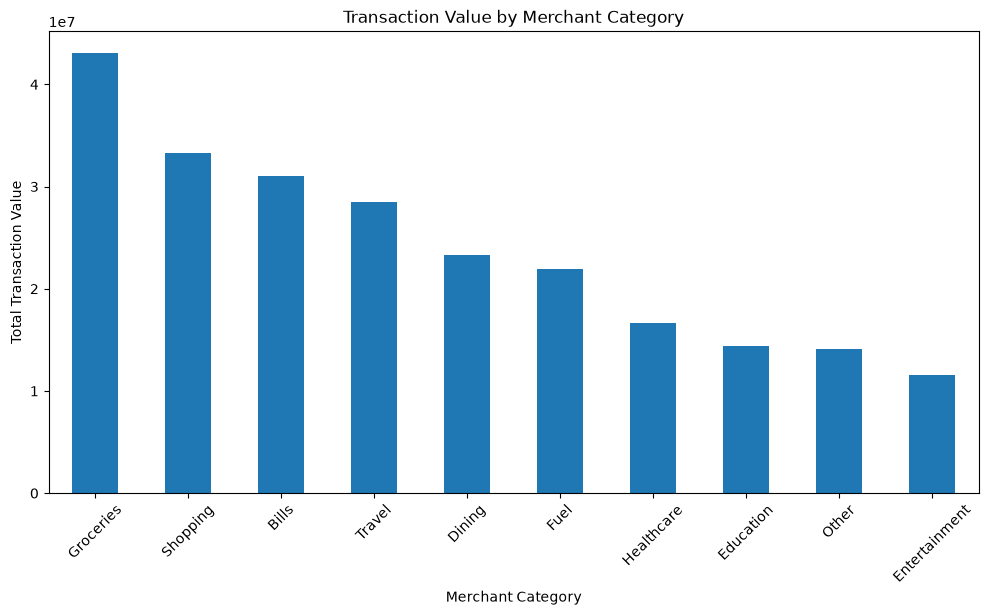

In [54]:
plt.figure(figsize=(12, 6))

merchant_value.plot(kind="bar")

plt.title("Transaction Value by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Total Transaction Value")
plt.xticks(rotation=45)

plt.show()

In [55]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    errors="coerce"
)

C:\Users\shash\AppData\Local\Temp\ipykernel_15152\2009073931.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  transactions["transaction_date"] = pd.to_datetime(


In [56]:
transactions["transaction_date"].dtype

dtype('<M8[us]')

In [57]:
monthly_value = (
    transactions
    .set_index("transaction_date")
    .resample("ME")["amount"]
    .sum()
)

monthly_value

transaction_date
2025-01-31    13123018.42
2025-02-28    12526086.19
2025-03-31    12867603.35
2025-04-30    13337237.54
2025-05-31    14205412.65
2025-06-30    12697826.26
2025-07-31    13500356.83
2025-08-31    14098089.20
2025-09-30    13350875.24
2025-10-31    13227305.66
2025-11-30    12943157.62
2025-12-31    14316550.31
2026-01-31    13445309.62
2026-02-28    11707837.68
2026-03-31    12986918.11
2026-04-30    12829159.50
2026-05-31    13323323.12
2026-06-30    13241035.05
Name: amount, dtype: float64

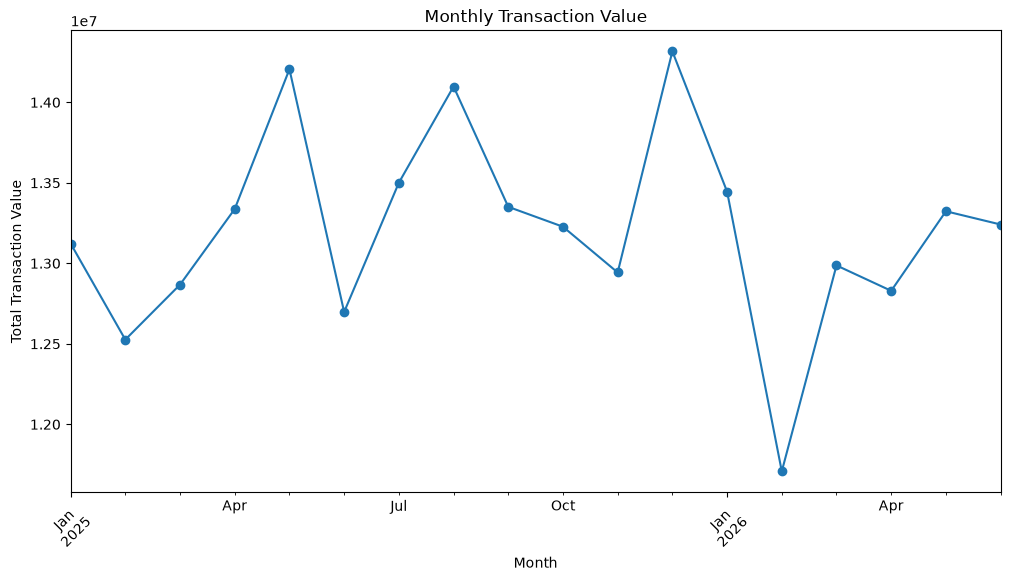

In [58]:
plt.figure(figsize=(12, 6))

monthly_value.plot(marker="o")

plt.title("Monthly Transaction Value")
plt.xlabel("Month")
plt.ylabel("Total Transaction Value")
plt.xticks(rotation=45)

plt.show()

In [59]:
monthly_count = (
    transactions
    .set_index("transaction_date")
    .resample("ME")["transaction_id"]
    .count()
)

monthly_count

transaction_date
2025-01-31    4464
2025-02-28    4162
2025-03-31    4451
2025-04-30    4497
2025-05-31    4684
2025-06-30    4425
2025-07-31    4459
2025-08-31    4707
2025-09-30    4441
2025-10-31    4471
2025-11-30    4287
2025-12-31    4654
2026-01-31    4546
2026-02-28    3994
2026-03-31    4450
2026-04-30    4360
2026-05-31    4531
2026-06-30    4416
Name: transaction_id, dtype: int64

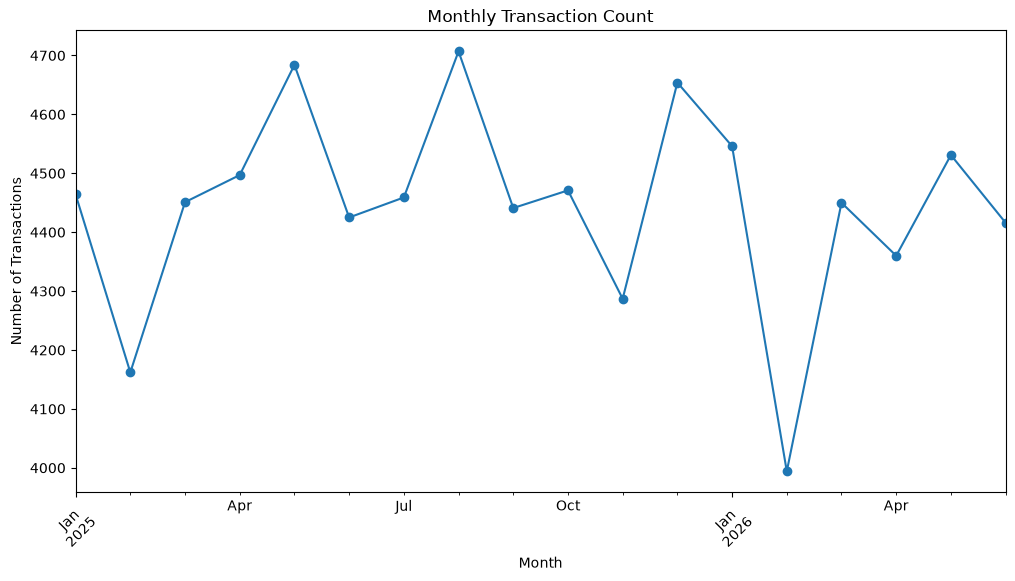

In [60]:
plt.figure(figsize=(12, 6))

monthly_count.plot(marker="o")

plt.title("Monthly Transaction Count")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [61]:
monthly_avg = (
    transactions
    .set_index("transaction_date")
    .resample("ME")["amount"]
    .mean()
)

monthly_avg

transaction_date
2025-01-31    2939.744270
2025-02-28    3009.631473
2025-03-31    2890.946608
2025-04-30    2965.807770
2025-05-31    3032.752487
2025-06-30    2869.565256
2025-07-31    3027.664685
2025-08-31    2995.132611
2025-09-30    3006.276794
2025-10-31    2958.466934
2025-11-30    3019.164362
2025-12-31    3076.181846
2026-01-31    2957.613203
2026-02-28    2931.356455
2026-03-31    2918.408564
2026-04-30    2942.467775
2026-05-31    2940.481819
2026-06-30    2998.422792
Name: amount, dtype: float64

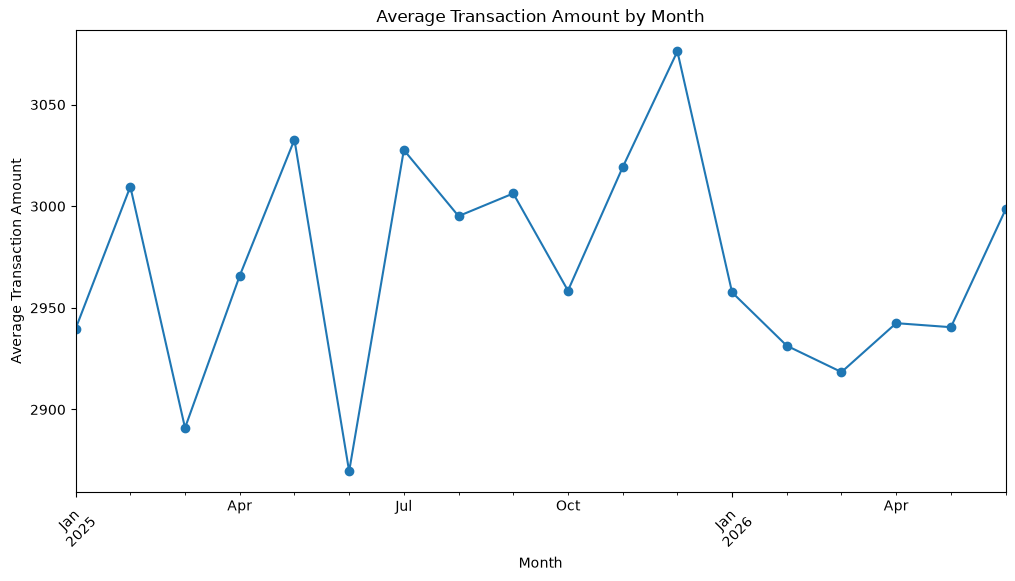

In [62]:
plt.figure(figsize=(12, 6))

monthly_avg.plot(marker="o")

plt.title("Average Transaction Amount by Month")
plt.xlabel("Month")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=45)

plt.show()

In [63]:
customer_txn = (
    transactions
    .groupby("customer_id")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        avg_transaction_amount=("amount", "mean")
    )
    .sort_values("total_transaction_value", ascending=False)
)

customer_txn.head(10)

,transaction_count,total_transaction_value,avg_transaction_amount
customer_id,,,
C102546,22,184341.79,8379.172273
C104743,18,173336.84,9629.824444
C103325,19,172724.61,9090.768947
C103356,23,149386.41,6495.061304
C102874,16,147609.06,9225.566250
C100808,23,144320.45,6274.802174
C101140,19,143898.02,7573.580000
C100061,25,138110.13,5524.405200
C103878,24,135562.91,5648.454583


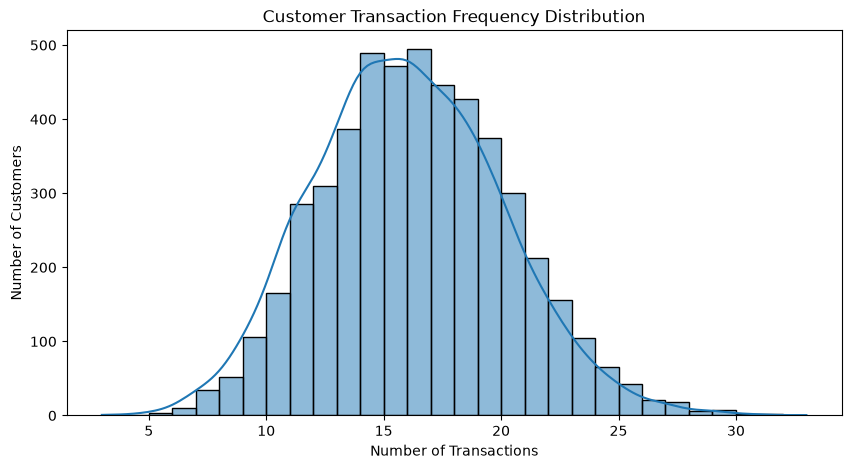

In [64]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_txn["transaction_count"],
    bins=30,
    kde=True
)

plt.title("Customer Transaction Frequency Distribution")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

plt.show()

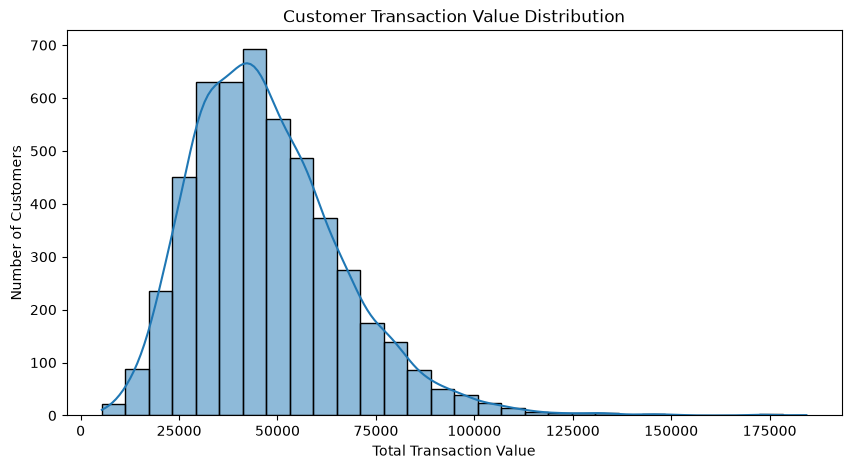

In [65]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_txn["total_transaction_value"],
    bins=30,
    kde=True
)

plt.title("Customer Transaction Value Distribution")
plt.xlabel("Total Transaction Value")
plt.ylabel("Number of Customers")

plt.show()

In [66]:
top_customers = (
    customer_txn
    .head(10)
)

top_customers

,transaction_count,total_transaction_value,avg_transaction_amount
customer_id,,,
C102546,22,184341.79,8379.172273
C104743,18,173336.84,9629.824444
C103325,19,172724.61,9090.768947
C103356,23,149386.41,6495.061304
C102874,16,147609.06,9225.566250
C100808,23,144320.45,6274.802174
C101140,19,143898.02,7573.580000
C100061,25,138110.13,5524.405200
C103878,24,135562.91,5648.454583


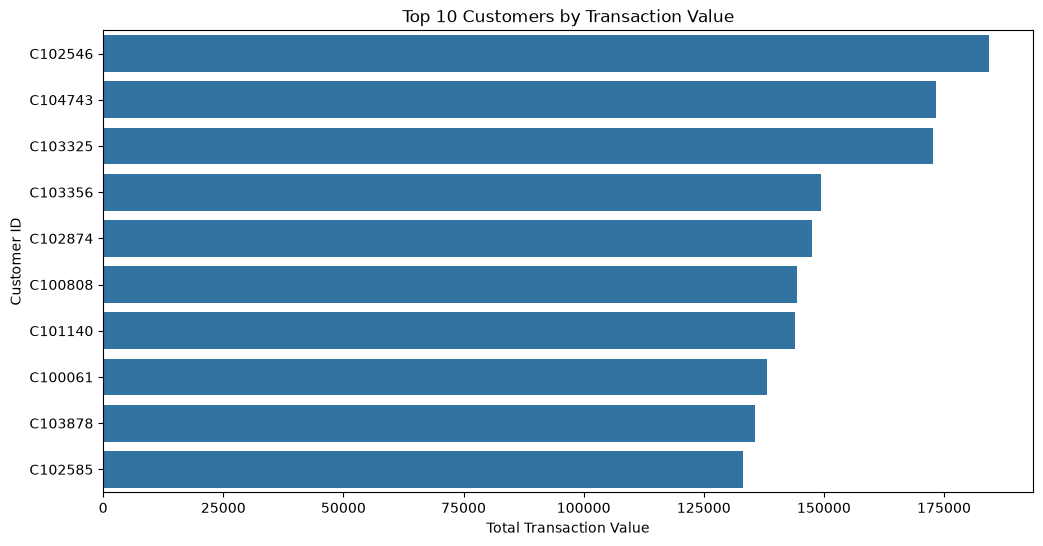

In [67]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_customers["total_transaction_value"],
    y=top_customers.index.astype(str)
)

plt.title("Top 10 Customers by Transaction Value")
plt.xlabel("Total Transaction Value")
plt.ylabel("Customer ID")

plt.show()

In [68]:
customer_behavior = pd.read_sql(
    "SELECT * FROM customer_behaviours",
    conn
)

C:\Users\shash\AppData\Local\Temp\ipykernel_15152\2388992878.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer_behavior = pd.read_sql(


In [69]:
customer_behavior.head()

,customer_id,monthly_txn_avg,last_transaction_date,complaint_count,login_frequency_monthly,churn_probability,churn_flag,Risk_Segment
0,C100000,1.1,21-06-2026,0,17,0.135,No,Low Risk
1,C100001,1.0,02-03-2026,1,14,0.160,No,Medium Risk
2,C100002,0.6,29-04-2026,0,6,0.135,No,Low Risk
3,C100003,1.1,30-06-2026,2,3,0.195,Yes,Medium Risk
4,C100004,0.8,24-06-2026,1,4,0.135,Yes,Medium Risk


In [70]:
high_value_churn = (
    customer_analysis
    .sort_values("total_transaction_value", ascending=False)
    .head(10)
)

high_value_churn[
    [
        "customer_id",
        "transaction_count",
        "total_transaction_value",
        "avg_transaction_amount",
        "churn_probability",
        "churn_flag",
        "complaint_count",
        "login_frequency_monthly"
    ]
]

NameError: name 'customer_analysis' is not defined

In [71]:
customer_txn = (
    transactions
    .groupby("customer_id")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        avg_transaction_amount=("amount", "mean")
    )
    .reset_index()
)

In [72]:
customer_behavior = pd.read_sql(
    "SELECT * FROM customer_behaviours",
    conn
)

C:\Users\shash\AppData\Local\Temp\ipykernel_15152\2388992878.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer_behavior = pd.read_sql(


In [73]:
customer_analysis = customer_txn.merge(
    customer_behavior[
        [
            "customer_id",
            "churn_probability",
            "churn_flag",
            "complaint_count",
            "login_frequency_monthly"
        ]
    ],
    on="customer_id",
    how="left"
)

In [74]:
customer_analysis.head()

,customer_id,transaction_count,total_transaction_value,avg_transaction_amount,churn_probability,churn_flag,complaint_count,login_frequency_monthly
0,C100000,19,38952.50,2050.131579,0.135,No,0,17
1,C100001,18,57776.90,3209.827778,0.160,No,1,14
2,C100002,10,20855.07,2085.507000,0.135,No,0,6
3,C100003,19,47091.19,2478.483684,0.195,Yes,2,3
4,C100004,14,17382.02,1241.572857,0.135,Yes,1,4


In [75]:
high_value_churn = (
    customer_analysis
    .sort_values("total_transaction_value", ascending=False)
    .head(10)
)

high_value_churn[
    [
        "customer_id",
        "transaction_count",
        "total_transaction_value",
        "avg_transaction_amount",
        "churn_probability",
        "churn_flag",
        "complaint_count",
        "login_frequency_monthly"
    ]
]

,customer_id,transaction_count,total_transaction_value,avg_transaction_amount,churn_probability,churn_flag,complaint_count,login_frequency_monthly
2546,C102546,22,184341.79,8379.172273,0.135,No,0,6
4743,C104743,18,173336.84,9629.824444,0.135,No,0,7
3325,C103325,19,172724.61,9090.768947,0.160,No,2,10
3356,C103356,23,149386.41,6495.061304,0.135,No,0,5
2874,C102874,16,147609.06,9225.566250,0.160,No,2,11
808,C100808,23,144320.45,6274.802174,0.160,No,2,5
1140,C101140,19,143898.02,7573.580000,0.160,No,1,9
61,C100061,25,138110.13,5524.405200,0.135,No,0,5
3878,C103878,24,135562.91,5648.454583,0.135,No,1,7
2585,C102585,25,133117.09,5324.683600,0.135,No,1,13


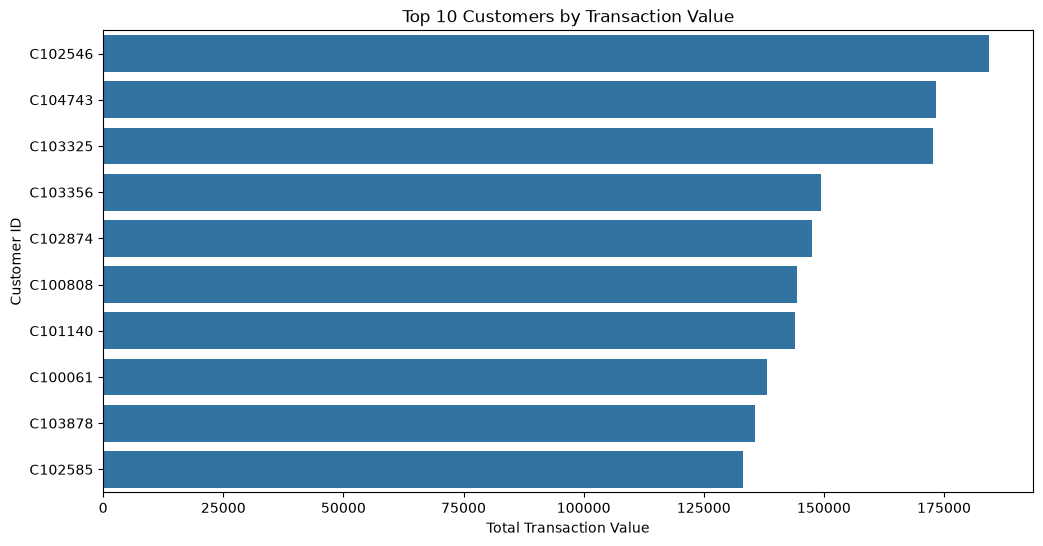

In [76]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_customers["total_transaction_value"],
    y=top_customers.index.astype(str)
)

plt.title("Top 10 Customers by Transaction Value")
plt.xlabel("Total Transaction Value")
plt.ylabel("Customer ID")

plt.show()

In [77]:
churn_counts = customer_behavior["churn_flag"].value_counts()

churn_counts

churn_flag
No     4292
Yes     708
Name: count, dtype: int64

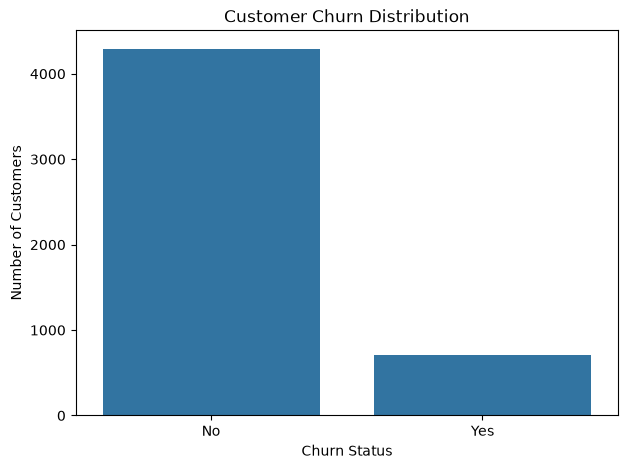

In [78]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=customer_behavior,
    x="churn_flag"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [79]:
customer_behavior["complaint_group"] = np.where(
    customer_behavior["complaint_count"] == 0,
    "No Complaints",
    "1+ Complaints"
)

In [80]:
complaint_churn = (
    customer_behavior
    .groupby("complaint_group")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_flag", lambda x: (x == "Yes").sum())
    )
)

complaint_churn["churn_rate"] = (
    complaint_churn["churned_customers"]
    / complaint_churn["total_customers"]
    * 100
)

complaint_churn

,total_customers,churned_customers,churn_rate
complaint_group,,,
1+ Complaints,2934,435,14.826176
No Complaints,2066,273,13.213940


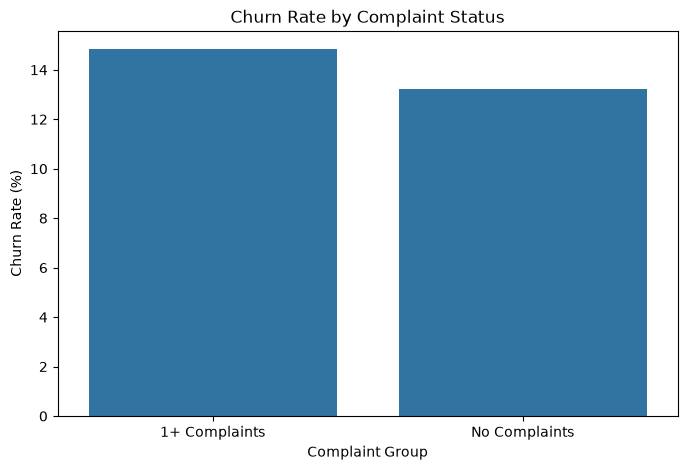

In [81]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=complaint_churn.index,
    y=complaint_churn["churn_rate"]
)

plt.title("Churn Rate by Complaint Status")
plt.xlabel("Complaint Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [82]:
customer_behavior["engagement_group"] = np.select(
    [
        customer_behavior["login_frequency_monthly"] < 5,
        customer_behavior["login_frequency_monthly"] < 10
    ],
    [
        "Low Engagement",
        "Medium Engagement"
    ],
    default="High Engagement"
)

In [83]:
engagement_churn = (
    customer_behavior
    .groupby("engagement_group")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_flag", lambda x: (x == "Yes").sum())
    )
)

engagement_churn["churn_rate"] = (
    engagement_churn["churned_customers"]
    / engagement_churn["total_customers"]
    * 100
)

engagement_churn

,total_customers,churned_customers,churn_rate
engagement_group,,,
High Engagement,2292,323,14.092496
Low Engagement,612,98,16.013072
Medium Engagement,2096,287,13.692748


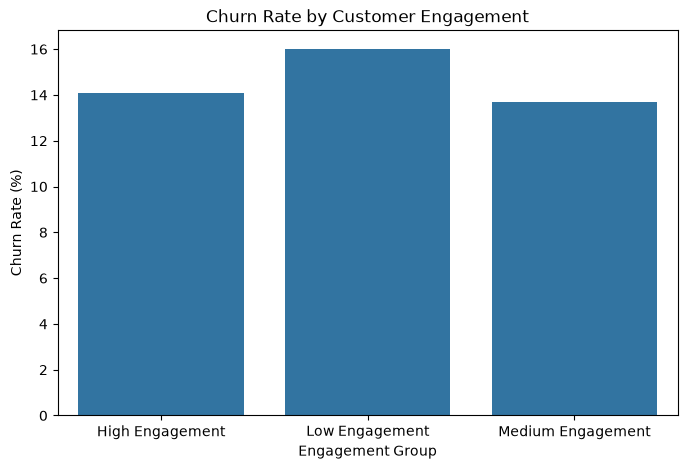

In [84]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=engagement_churn.reset_index(),
    x="engagement_group",
    y="churn_rate"
)

plt.title("Churn Rate by Customer Engagement")
plt.xlabel("Engagement Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [85]:
customer_full = customers.merge(
    customer_behavior,
    on="customer_id",
    how="left"
)

customer_full.head()

,customer_id,age,gender,city,occupation,annual_income,customer_since,state,income_band,monthly_txn_avg,last_transaction_date,complaint_count,login_frequency_monthly,churn_probability,churn_flag,Risk_Segment,complaint_group,engagement_group
0,C102908,51,Female,Bengaluru,Business Owner,2561400.0,24-02-2020,Karnataka,High,0.8,25-06-2026,0,8,0.135,No,Low Risk,No Complaints,Medium Engagement
1,C101971,42,Male,Delhi,IT Professional,2250900.0,09-06-2019,Delhi,High,0.8,10-04-2026,0,11,0.135,No,Low Risk,No Complaints,High Engagement
2,C102209,50,Male,Kolkata,Government Employee,2180800.0,28-05-2019,West Bengal,High,1.1,29-06-2026,1,3,0.170,No,Medium Risk,1+ Complaints,Low Engagement
3,C101745,46,Female,Pune,Government Employee,2163400.0,06-12-2024,Maharashtra,High,0.7,15-05-2026,1,12,0.135,No,Medium Risk,1+ Complaints,High Engagement
4,C103962,39,Male,Delhi,Self Employed,2149500.0,21-05-2022,Delhi,High,0.5,29-03-2026,3,13,0.185,No,Medium Risk,1+ Complaints,High Engagement


In [86]:
income_churn = (
    customer_full
    .groupby("income_band")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_flag", lambda x: (x == "Yes").sum())
    )
)

income_churn["churn_rate"] = (
    income_churn["churned_customers"]
    / income_churn["total_customers"]
    * 100
)

income_churn.sort_values("churn_rate", ascending=False)

,total_customers,churned_customers,churn_rate
income_band,,,
Lower-Middle,2436,367,15.065681
Upper-Middle,1664,225,13.521635
High,440,59,13.409091
Low,459,57,12.418301


In [88]:
value_median = customer_analysis["total_transaction_value"].median()
frequency_median = customer_analysis["transaction_count"].median()
churn_median = customer_analysis["churn_probability"].median()

print("Transaction Value Median:", value_median)
print("Transaction Frequency Median:", frequency_median)
print("Churn Probability Median:", churn_median)

Transaction Value Median: 44855.375
Transaction Frequency Median: 16.0
Churn Probability Median: 0.135


In [89]:
customer_analysis["value_segment"] = np.where(
    customer_analysis["total_transaction_value"] >= value_median,
    "High Value",
    "Low Value"
)

In [90]:
customer_analysis["customer_segment"] = (
    customer_analysis["value_segment"]
    + " / "
    + customer_analysis["risk_segment"]
)

KeyError: 'risk_segment'

In [91]:
# Step 25 — Customer Segmentation

# 1. Calculate median thresholds
value_median = customer_analysis["total_transaction_value"].median()
churn_median = customer_analysis["churn_probability"].median()

print("Transaction Value Median:", value_median)
print("Churn Probability Median:", churn_median)


# 2. Create value segment
customer_analysis["value_segment"] = np.where(
    customer_analysis["total_transaction_value"] >= value_median,
    "High Value",
    "Low Value"
)


# 3. Create risk segment
customer_analysis["risk_segment"] = np.where(
    customer_analysis["churn_probability"] >= churn_median,
    "Higher Risk",
    "Lower Risk"
)


# 4. Combine both
customer_analysis["customer_segment"] = (
    customer_analysis["value_segment"]
    + " / "
    + customer_analysis["risk_segment"]
)


# 5. Check segment sizes
print("\nCustomer Segment Distribution:")
print(customer_analysis["customer_segment"].value_counts())


# 6. Create segment summary
segment_summary = (
    customer_analysis
    .groupby("customer_segment")
    .agg(
        customers=("customer_id", "count"),
        avg_transaction_value=("total_transaction_value", "mean"),
        avg_transaction_count=("transaction_count", "mean"),
        avg_churn_probability=("churn_probability", "mean"),
        churned_customers=("churn_flag", lambda x: (x == "Yes").sum())
    )
)

# 7. Calculate churn rate
segment_summary["churn_rate"] = (
    segment_summary["churned_customers"]
    / segment_summary["customers"]
    * 100
)

segment_summary

Transaction Value Median: 44855.375
Churn Probability Median: 0.135

Customer Segment Distribution:
customer_segment
Low Value / Higher Risk     2500
High Value / Higher Risk    2500
Name: count, dtype: int64


,customers,avg_transaction_value,avg_transaction_count,avg_churn_probability,churned_customers,churn_rate
customer_segment,,,,,,
High Value / Higher Risk,2500,62367.228484,18.0852,0.144982,365,14.60
Low Value / Higher Risk,2500,32723.612456,13.9148,0.145394,343,13.72


In [92]:
segment_summary.round(2)

,customers,avg_transaction_value,avg_transaction_count,avg_churn_probability,churned_customers,churn_rate
customer_segment,,,,,,
High Value / Higher Risk,2500,62367.23,18.09,0.14,365,14.60
Low Value / Higher Risk,2500,32723.61,13.91,0.15,343,13.72


In [93]:
customer_analysis["customer_segment"].value_counts()

customer_segment
Low Value / Higher Risk     2500
High Value / Higher Risk    2500
Name: count, dtype: int64

In [94]:
segment_summary = (
    customer_analysis
    .groupby("customer_segment")
    .agg(
        customers=("customer_id", "count"),
        avg_transaction_value=("total_transaction_value", "mean"),
        avg_transaction_count=("transaction_count", "mean"),
        avg_churn_probability=("churn_probability", "mean"),
        churned_customers=("churn_flag", lambda x: (x == "Yes").sum())
    )
)

segment_summary["churn_rate"] = (
    segment_summary["churned_customers"]
    / segment_summary["customers"]
    * 100
)

segment_summary.sort_values(
    "avg_transaction_value",
    ascending=False
)

,customers,avg_transaction_value,avg_transaction_count,avg_churn_probability,churned_customers,churn_rate
customer_segment,,,,,,
High Value / Higher Risk,2500,62367.228484,18.0852,0.144982,365,14.60
Low Value / Higher Risk,2500,32723.612456,13.9148,0.145394,343,13.72


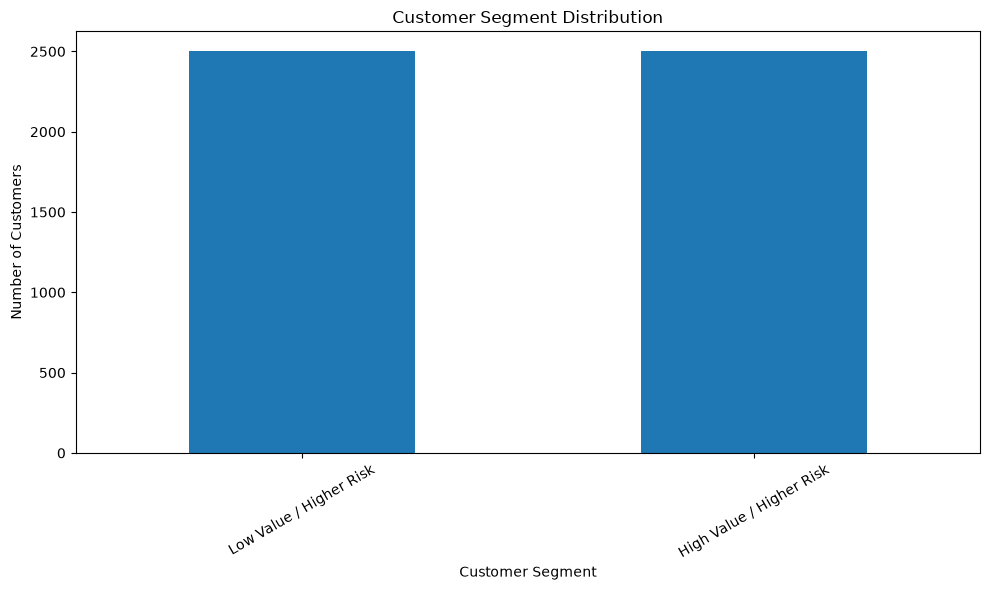

In [95]:
import matplotlib.pyplot as plt

segment_counts = customer_analysis["customer_segment"].value_counts()

plt.figure(figsize=(10, 6))
segment_counts.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [96]:
# Step 27 — High-Value Customers at Risk

high_value_at_risk = customer_analysis[
    (customer_analysis["value_segment"] == "High Value") &
    (customer_analysis["risk_segment"] == "Higher Risk")
].copy()

high_value_at_risk = high_value_at_risk.sort_values(
    "total_transaction_value",
    ascending=False
)

high_value_at_risk[
    [
        "customer_id",
        "transaction_count",
        "total_transaction_value",
        "avg_transaction_amount",
        "churn_probability",
        "churn_flag",
        "complaint_count",
        "login_frequency_monthly"
    ]
].head(20)

,customer_id,transaction_count,total_transaction_value,avg_transaction_amount,churn_probability,churn_flag,complaint_count,login_frequency_monthly
2546,C102546,22,184341.79,8379.172273,0.135,No,0,6
4743,C104743,18,173336.84,9629.824444,0.135,No,0,7
3325,C103325,19,172724.61,9090.768947,0.160,No,2,10
3356,C103356,23,149386.41,6495.061304,0.135,No,0,5
2874,C102874,16,147609.06,9225.566250,0.160,No,2,11
808,C100808,23,144320.45,6274.802174,0.160,No,2,5
1140,C101140,19,143898.02,7573.580000,0.160,No,1,9
61,C100061,25,138110.13,5524.405200,0.135,No,0,5
3878,C103878,24,135562.91,5648.454583,0.135,No,1,7
2585,C102585,25,133117.09,5324.683600,0.135,No,1,13


In [97]:
# Step 28 — Correlation Analysis

correlation_data = customer_analysis[
    [
        "transaction_count",
        "total_transaction_value",
        "avg_transaction_amount",
        "complaint_count",
        "login_frequency_monthly",
        "churn_probability"
    ]
]

correlation_matrix = correlation_data.corr()

print(correlation_matrix.round(2))

                         transaction_count  total_transaction_value  \
transaction_count                     1.00                     0.61   
total_transaction_value               0.61                     1.00   
avg_transaction_amount                0.00                     0.77   
complaint_count                       0.02                     0.02   
login_frequency_monthly               0.01                    -0.01   
churn_probability                    -0.06                    -0.03   

                         avg_transaction_amount  complaint_count  \
transaction_count                          0.00             0.02   
total_transaction_value                    0.77             0.02   
avg_transaction_amount                     1.00             0.01   
complaint_count                            0.01             1.00   
login_frequency_monthly                   -0.01             0.02   
churn_probability                          0.02             0.56   

                         

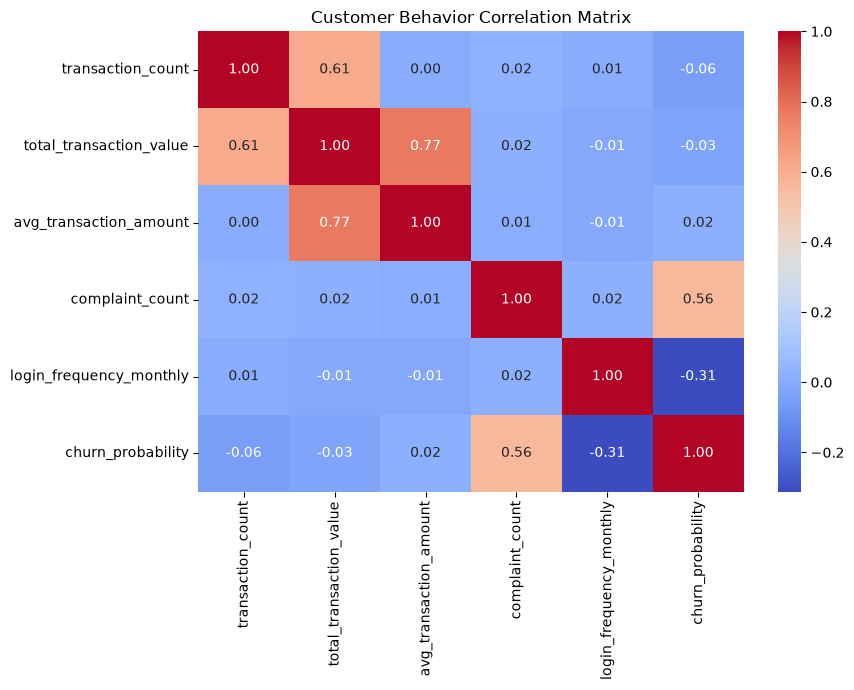

In [98]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Customer Behavior Correlation Matrix")
plt.tight_layout()
plt.show()

In [99]:
# Step 29 — Churn by Engagement

engagement_churn = (
    customer_behavior
    .groupby("engagement_group")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_flag", lambda x: (x == "Yes").sum())
    )
)

engagement_churn["churn_rate"] = (
    engagement_churn["churned_customers"]
    / engagement_churn["total_customers"]
    * 100
)

engagement_churn = engagement_churn.sort_values(
    "churn_rate",
    ascending=False
)

print(engagement_churn.round(2))

                   total_customers  churned_customers  churn_rate
engagement_group                                                 
Low Engagement                 612                 98       16.01
High Engagement               2292                323       14.09
Medium Engagement             2096                287       13.69


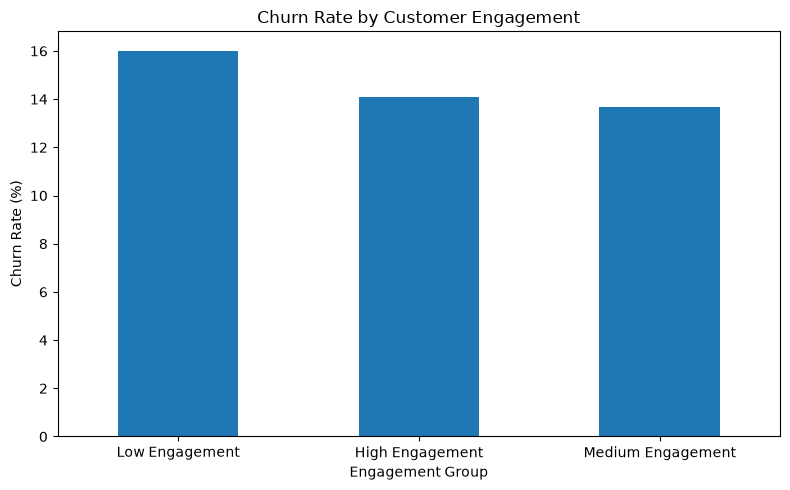

In [100]:
plt.figure(figsize=(8, 5))

engagement_churn["churn_rate"].plot(kind="bar")

plt.title("Churn Rate by Customer Engagement")
plt.xlabel("Engagement Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [101]:
# Step 30 — Churn by Income Band

income_churn = (
    customer_full
    .groupby("income_band")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_flag", lambda x: (x == "Yes").sum())
    )
)

income_churn["churn_rate"] = (
    income_churn["churned_customers"]
    / income_churn["total_customers"]
    * 100
)

income_churn = income_churn.sort_values(
    "churn_rate",
    ascending=False
)

print(income_churn.round(2))

              total_customers  churned_customers  churn_rate
income_band                                                 
Lower-Middle             2436                367       15.07
Upper-Middle             1664                225       13.52
High                      440                 59       13.41
Low                       459                 57       12.42


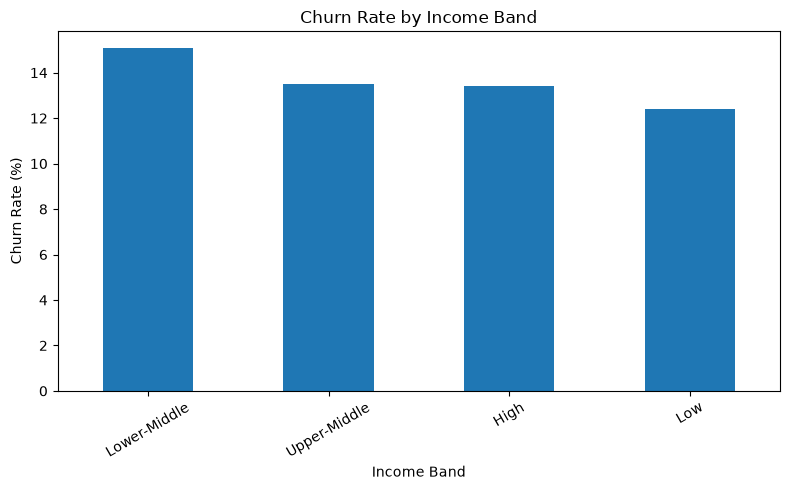

In [102]:
plt.figure(figsize=(8, 5))

income_churn["churn_rate"].plot(kind="bar")

plt.title("Churn Rate by Income Band")
plt.xlabel("Income Band")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

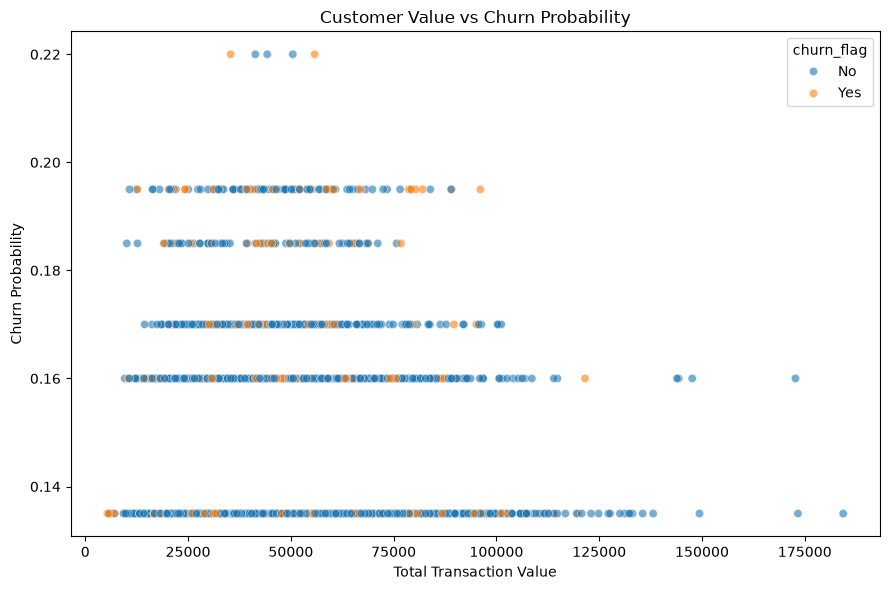

In [103]:
# Step 31 — Customer Value vs Churn Probability

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_analysis,
    x="total_transaction_value",
    y="churn_probability",
    hue="churn_flag",
    alpha=0.6
)

plt.title("Customer Value vs Churn Probability")
plt.xlabel("Total Transaction Value")
plt.ylabel("Churn Probability")
plt.tight_layout()
plt.show()

In [104]:
# Step 32 — Final Python EDA Summary

python_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Transactions",
        "Total Transaction Value",
        "Average Transaction Value",
        "Churned Customers",
        "Overall Churn Rate",
        "Average Churn Probability",
        "Average Monthly Login Frequency",
        "Total Complaints",
        "Total Loans"
    ],
    "Value": [
        customer_analysis["customer_id"].nunique(),
        transactions["transaction_id"].nunique(),
        transactions["amount"].sum(),
        transactions["amount"].mean(),
        (customer_behavior["churn_flag"] == "Yes").sum(),
        (customer_behavior["churn_flag"] == "Yes").mean() * 100,
        customer_behavior["churn_probability"].mean(),
        customer_behavior["login_frequency_monthly"].mean(),
        complaint.shape[0],
        loan1.shape[0]
    ]
})

python_summary

NameError: name 'complaint' is not defined

In [105]:
python_summary["Value"] = python_summary["Value"].round(2)

python_summary

NameError: name 'python_summary' is not defined

In [106]:
# Step 32 — Final Python EDA Summary

python_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Transactions",
        "Total Transaction Value",
        "Average Transaction Value",
        "Churned Customers",
        "Overall Churn Rate",
        "Average Churn Probability",
        "Average Monthly Login Frequency",
        "Total Complaints",
        "Total Loans"
    ],
    "Value": [
        customer_analysis["customer_id"].nunique(),
        transactions["transaction_id"].nunique(),
        transactions["amount"].sum(),
        transactions["amount"].mean(),
        (customer_behavior["churn_flag"] == "Yes").sum(),
        (customer_behavior["churn_flag"] == "Yes").mean() * 100,
        customer_behavior["churn_probability"].mean(),
        customer_behavior["login_frequency_monthly"].mean(),
        complaint.shape[0],
        loan1.shape[0]
    ]
})

python_summary["Value"] = python_summary["Value"].round(2)

python_summary

NameError: name 'complaint' is not defined

In [107]:
# Step 32 — Final Python EDA Summary

python_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Transactions",
        "Total Transaction Value",
        "Average Transaction Value",
        "Churned Customers",
        "Overall Churn Rate",
        "Average Churn Probability",
        "Average Monthly Login Frequency",
        "Total Complaints",
        "Total Loans"
    ],
    "Value": [
        customer_analysis["customer_id"].nunique(),
        transactions["transaction_id"].nunique(),
        transactions["amount"].sum(),
        transactions["amount"].mean(),
        (customer_behavior["churn_flag"] == "Yes").sum(),
        (customer_behavior["churn_flag"] == "Yes").mean() * 100,
        customer_behavior["churn_probability"].mean(),
        customer_behavior["login_frequency_monthly"].mean(),
        4500,
        3000
    ]
})

python_summary["Value"] = python_summary["Value"].round(2)

python_summary

,Metric,Value
0,Total Customers,5.000000e+03
1,Total Transactions,8.000000e+04
2,Total Transaction Value,2.377271e+08
3,Average Transaction Value,2.971630e+03
4,Churned Customers,7.080000e+02
5,Overall Churn Rate,1.416000e+01
6,Average Churn Probability,1.500000e-01
7,Average Monthly Login Frequency,9.120000e+00
8,Total Complaints,4.500000e+03
9,Total Loans,3.000000e+03
